In [28]:
#%load_ext autoreload
#%autoreload 2

In [36]:
import torch
import os
import sys
from GCN import GCN
from GraphSAGE import GraphSAGE
from GAT import GAT


# Import the custom dataset
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from Datasets.garesearch_dataset import GAResearchDataset

from torch_geometric.datasets import HeterophilousGraphDataset
from torch_geometric.loader import DataLoader
import numpy as np
import random
import time
from sklearn.metrics import f1_score, accuracy_score

def seed_torch(seed=0):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU
    #add to warn
    #torch.use_deterministic_algorithms(True, warn_only=True) 
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_torch(seed=42)


In [37]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cuda


In [38]:
args = {
      'device': device,
      'num_layers': 3,
      'hidden_dim': 256,
      'dropout': 0.3,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 0,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 0
  }

# Setup

In [40]:
#dataset = HeterophilousGraphDataset(root ='tmp/Amazon-ratings', name='Amazon-ratings')
dataset = GAResearchDataset(root ='tmp/roman-fasttext-custom', name='roman-fasttext')

In [42]:
num_features = dataset.num_features
num_classes = dataset.num_classes
num_nodes = dataset[0].num_nodes
num_edges = dataset[0].num_edges

print(f"Number of graphs in dataset: {len(dataset)}")
print(f"Number of features for each node: {num_features}")
print(f"Number of num_classes : {num_classes}")

print(f"Number of num_nodes : {num_nodes}")
print(f"Number of num_edges : {num_edges}")

Number of graphs in dataset: 1
Number of features for each node: 300
Number of num_classes : 18
Number of num_nodes : 22600
Number of num_edges : 65368


In [43]:
# Number of splits available
print(dataset[0].train_mask.shape)
print(dataset[0].test_mask.shape)
print(dataset[0].val_mask.shape)

torch.Size([22600, 10])
torch.Size([22600, 10])
torch.Size([22600, 10])


In [44]:
print(dataset[0].train_mask[:,args['split_idx']])
print(dataset[0].train_mask[:,args['split_idx']].shape)

tensor([ True, False,  True,  ...,  True, False,  True])
torch.Size([22600])


In [45]:
def train(model, data, optimizer, criterion):
    """
    one training epoch
    model -  GNN (GCNConv or GraphSAGE)
    data - Entire Graph Dataset i.e. dataset[0]
    optimizer - algorithm that updates model weights (Adam, SGD, etc.)
    criterion - loss function (often BCEWithLogitsLoss for the PPI dataset)
    """
    #Training mode
    model.train()
    #TODO: Move the data to device outside the training loop
    #data = data.to(device)
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    split_idx = args['split_idx']
    loss = criterion(out[data.train_mask[:,split_idx]], data.y[data.train_mask[:,split_idx]])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def test(model, data, mask, return_preds=False):
    """
    data: dataset[0] - 1 entire graph composed of all labeled train, test, val
    mask: array of [True, False, ....]
    """
    #switch to evaluation mode
    model.eval()
    # ys: Ground Truth Labels, preds: model predictions across all batches
    ys, preds = [], []

    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[mask].argmax(dim=1).cpu().numpy()
        y = data.y[mask].cpu().numpy()
    
    #macro - how model handles small classes
    f1 = f1_score(y, pred, average='macro', zero_division=0)
    #f1 = f1_score(y, pred, average='micro', zero_division=0)
    acc = accuracy_score(y, pred)

    if return_preds:
        return f1, acc, y, pred
    return f1, acc
        

In [47]:
def train_and_evaluate(model, data, optimizer, scheduler, criterion, epochs=100):
    best_val_f1 = 0
    train_losses, val_f1s, val_accs, test_f1s, test_accs = [],[],[],[],[]
    training_time = 0

    for epoch in range(1, epochs+1):
        start_time = time.time()

        loss = train(model, data, optimizer, criterion)
        
        if scheduler:
            scheduler.step()

        epoch_time = time.time() - start_time
        training_time += epoch_time

        split_idx = args['split_idx']
        val_f1, val_acc = test(model, data, data.val_mask[:,split_idx])
        test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])

        train_losses.append(loss)
        val_f1s.append(val_f1)
        test_f1s.append(test_f1)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model_gcn.pth')

        if epoch % 10 == 0:
            print(f"Epoch: {epoch:03d}, "
                f"Loss: {loss:.4f}, "
                f"Val F1: {val_f1:.4f},"
                f"Val Acc: {val_acc:.4f}, "
                f"Time: {epoch_time:.2f}s"
                )


    model.load_state_dict(torch.load('best_model_gcn.pth', map_location=device))
    test_f1, test_acc, y_true, y_pred = test(model, data, data.test_mask[:,split_idx], return_preds=True)
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize

    plt.figure(figsize=(14, 12))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=range(18), yticklabels=range(18))
    plt.title('Normalized Confusion Matrix: Roman Empire Syntactic Roles')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

    return model, train_losses, val_f1s, test_f1s, training_time

In [48]:
def build_optimizer(args, params):
    
    filter_fn = filter(lambda p : p.requires_grad, params)
    weight_decay = args['weight_decay']
    if args['opt'] == 'adam':
        optimizer = torch.optim.Adam(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'sgd':
        optimizer = torch.optim.SGD(filter_fn, lr=args['lr'], momentum=0.95, weight_decay=weight_decay)
    elif args['opt'] == 'rmsprop':
        optimizer = torch.optim.RMSprop(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'adagrad':
        optimizer = torch.optim.Adagrad(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    if args['opt_scheduler'] == 'none':
        return None, optimizer
    elif args['opt_scheduler'] == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args['opt_decay_step'], gamma=args['opt_decay_rate'])
    elif args['opt_scheduler'] == 'cos':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args['opt_restart'])
    return scheduler, optimizer

In [49]:
import matplotlib.pyplot as plt
def plot_results(results, title, label, ylabel):
    plt.figure(figsize=(3,2))
    epochs = range(1, len(results)+1)
    plt.plot(epochs, results, label = label)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

In [50]:
def gcn_run():
    model = GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN','F1 Score')


# GCN

Training GCN
Epoch: 010, Loss: 1.9279, Val F1: 0.0762,Val Acc: 0.2221, Time: 0.01s
Epoch: 020, Loss: 1.7340, Val F1: 0.0696,Val Acc: 0.2042, Time: 0.01s
Epoch: 030, Loss: 1.6160, Val F1: 0.1297,Val Acc: 0.2582, Time: 0.01s
Epoch: 040, Loss: 1.5109, Val F1: 0.2000,Val Acc: 0.2918, Time: 0.01s
Epoch: 050, Loss: 1.4064, Val F1: 0.2630,Val Acc: 0.3131, Time: 0.01s
Epoch: 060, Loss: 1.3001, Val F1: 0.2705,Val Acc: 0.3075, Time: 0.01s
Epoch: 070, Loss: 1.2059, Val F1: 0.2702,Val Acc: 0.2947, Time: 0.01s
Epoch: 080, Loss: 1.1177, Val F1: 0.2482,Val Acc: 0.2821, Time: 0.01s
Epoch: 090, Loss: 1.0340, Val F1: 0.2410,Val Acc: 0.2830, Time: 0.01s
Epoch: 100, Loss: 0.9617, Val F1: 0.2437,Val Acc: 0.2746, Time: 0.01s
Test F1: 0.2611
Test Accuracy: 0.3113


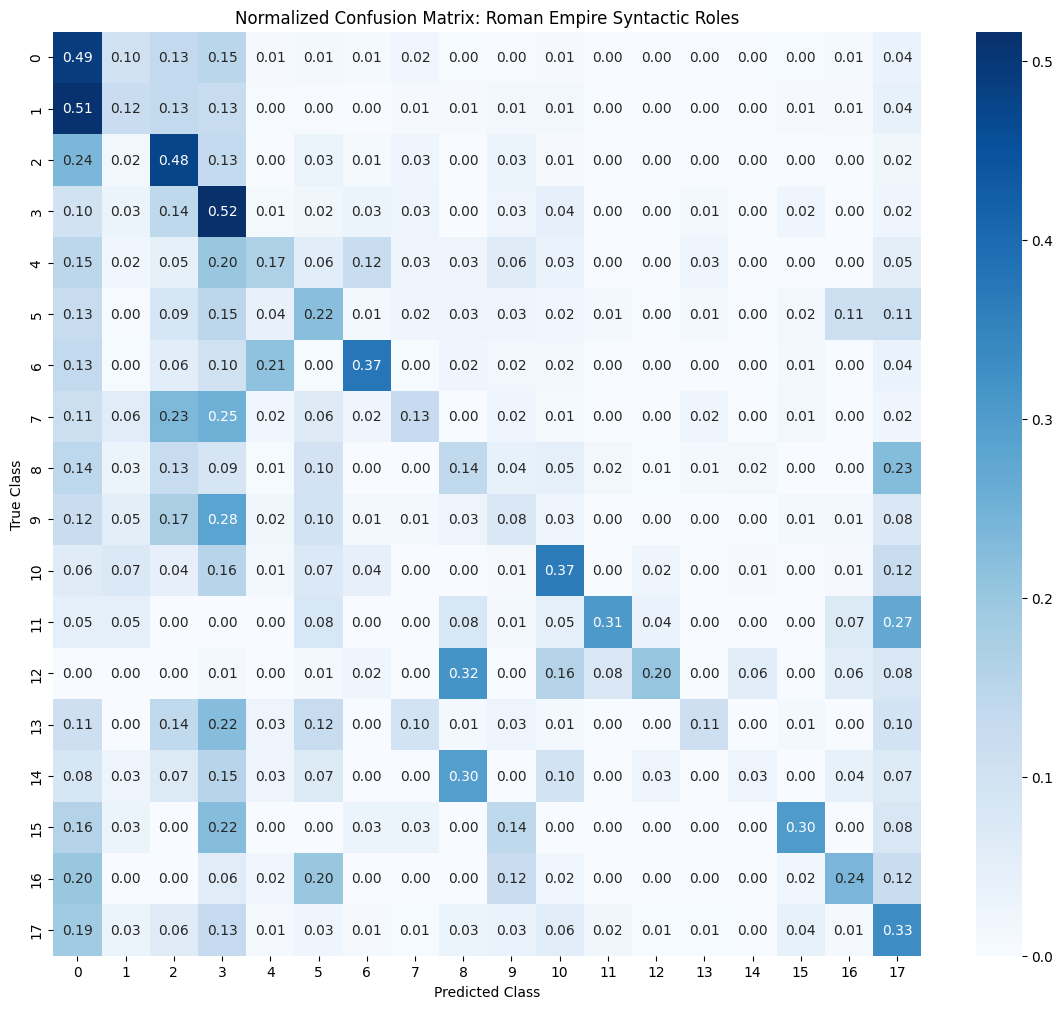

Training Time 9.587501049041748


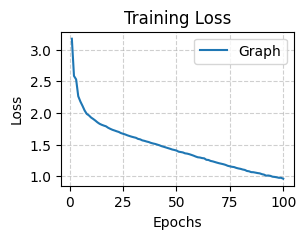

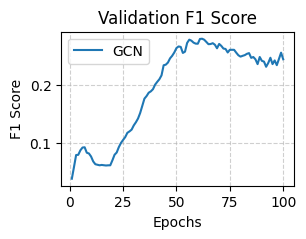

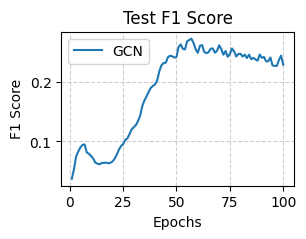

In [51]:
gcn_run()

In [52]:
def graphSage_run():
    model = GraphSAGE(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training Graph SAGE")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data,
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GraphSAGE','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GraphSAGE','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GraphSAGE','F1 Score')


Training Graph SAGE
Epoch: 010, Loss: 1.1246, Val F1: 0.4849,Val Acc: 0.6447, Time: 0.01s
Epoch: 020, Loss: 0.7808, Val F1: 0.6284,Val Acc: 0.7206, Time: 0.01s
Epoch: 030, Loss: 0.5930, Val F1: 0.6933,Val Acc: 0.7657, Time: 0.01s
Epoch: 040, Loss: 0.4610, Val F1: 0.7341,Val Acc: 0.7927, Time: 0.01s
Epoch: 050, Loss: 0.3427, Val F1: 0.7414,Val Acc: 0.7973, Time: 0.01s
Epoch: 060, Loss: 0.2587, Val F1: 0.7645,Val Acc: 0.8069, Time: 0.01s
Epoch: 070, Loss: 0.1859, Val F1: 0.7661,Val Acc: 0.8086, Time: 0.01s
Epoch: 080, Loss: 0.1300, Val F1: 0.7706,Val Acc: 0.8148, Time: 0.01s
Epoch: 090, Loss: 0.0922, Val F1: 0.7761,Val Acc: 0.8186, Time: 0.01s
Epoch: 100, Loss: 0.0691, Val F1: 0.7794,Val Acc: 0.8186, Time: 0.01s
Test F1: 0.7767
Test Accuracy: 0.8204


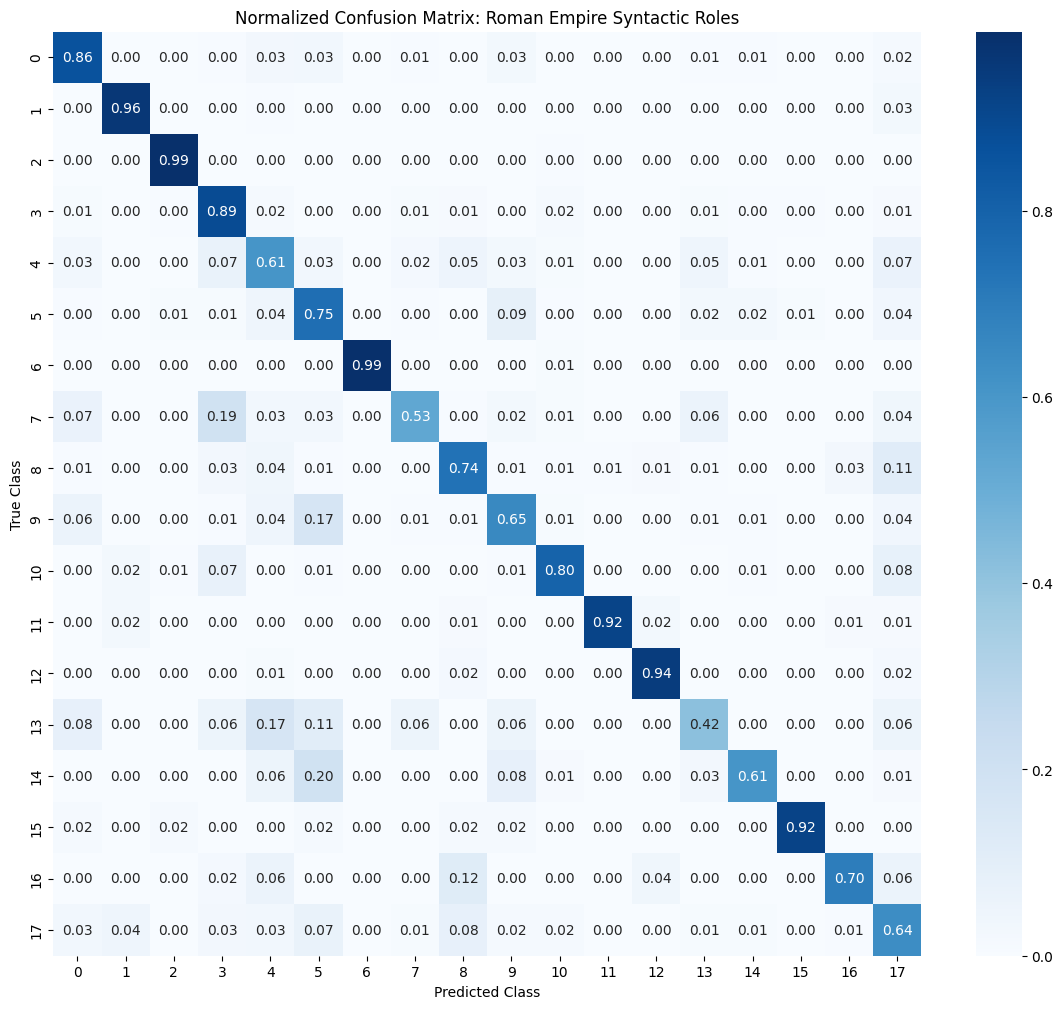

Training Time 1.328873634338379


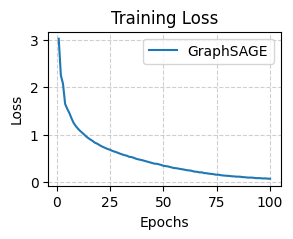

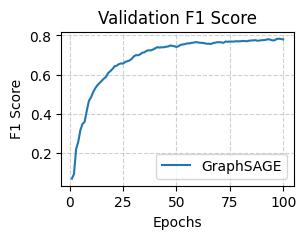

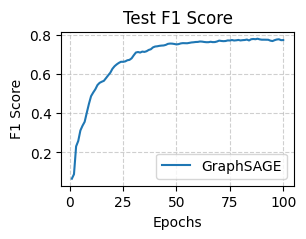

In [53]:
graphSage_run()

In [54]:
def gat_run():
    model = GAT(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'],
                heads=args['heads'],
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training GAT")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GAT','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GAT','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GAT','F1 Score')


Training GAT
Epoch: 010, Loss: 2.4199, Val F1: 0.0522,Val Acc: 0.1624, Time: 0.02s
Epoch: 020, Loss: 2.2026, Val F1: 0.1361,Val Acc: 0.2730, Time: 0.02s
Epoch: 030, Loss: 2.0716, Val F1: 0.1844,Val Acc: 0.2942, Time: 0.02s
Epoch: 040, Loss: 1.9813, Val F1: 0.2608,Val Acc: 0.3212, Time: 0.02s
Epoch: 050, Loss: 1.9173, Val F1: 0.2841,Val Acc: 0.3261, Time: 0.02s
Epoch: 060, Loss: 1.8657, Val F1: 0.2671,Val Acc: 0.3009, Time: 0.02s
Epoch: 070, Loss: 1.8164, Val F1: 0.2765,Val Acc: 0.3091, Time: 0.02s
Epoch: 080, Loss: 1.7704, Val F1: 0.2697,Val Acc: 0.2996, Time: 0.02s
Epoch: 090, Loss: 1.7274, Val F1: 0.2649,Val Acc: 0.2947, Time: 0.02s
Epoch: 100, Loss: 1.6778, Val F1: 0.2526,Val Acc: 0.2816, Time: 0.02s
Test F1: 0.2921
Test Accuracy: 0.3137


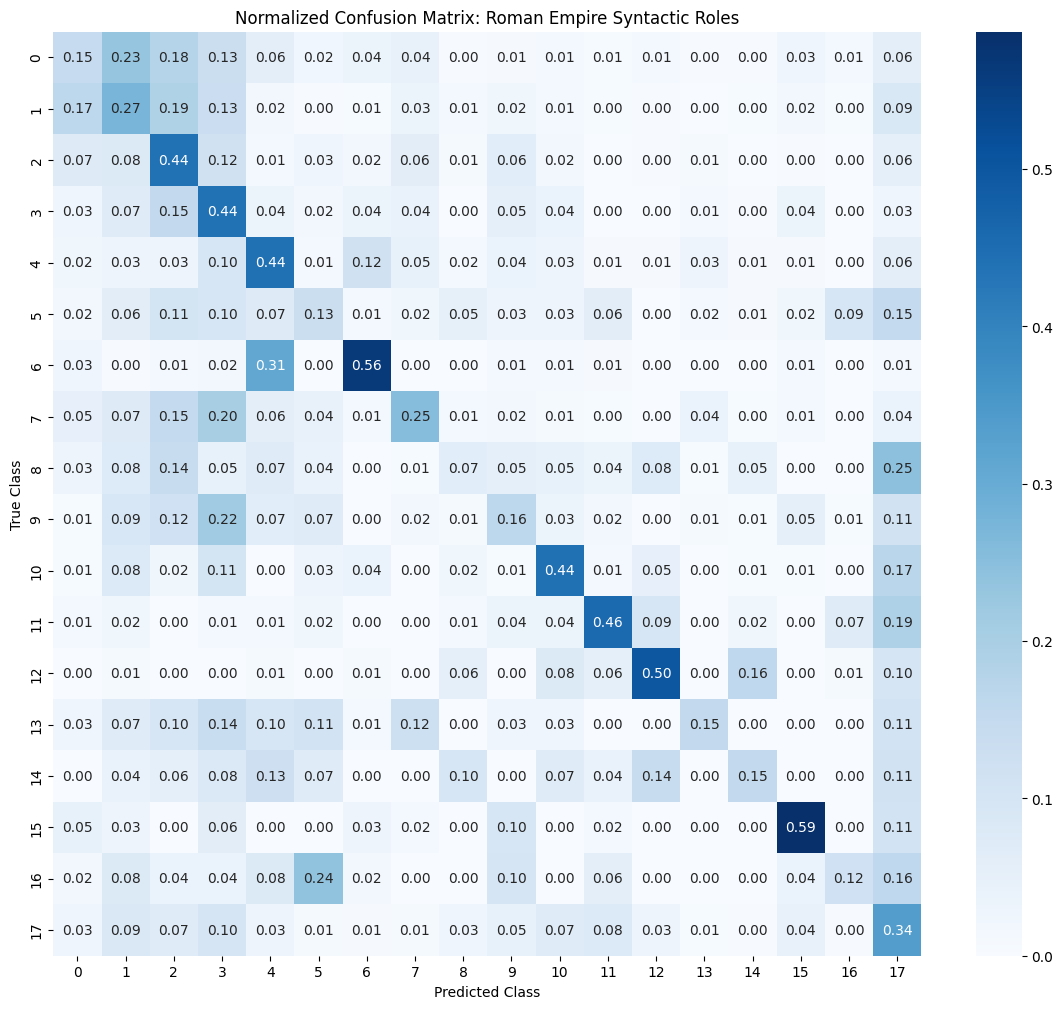

Training Time 3.1020314693450928


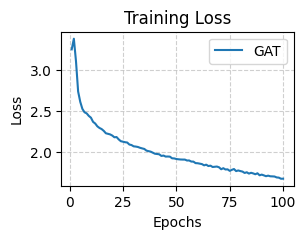

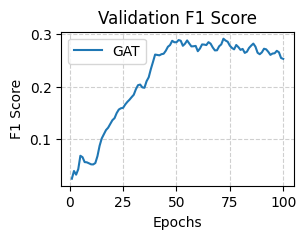

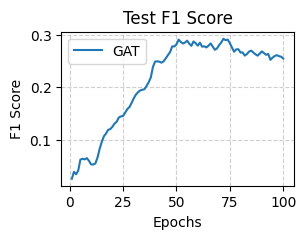

In [55]:
gat_run()

# GCN2Conv

In [56]:
from GCN2 import GCN2

In [57]:
args = {
      'device': device,
      'num_layers': 30,
      'hidden_dim': 256,
      'dropout': 0.5,
      'lr': 0.01,
      'epochs': 400,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [58]:
def gcn2_run():
    model = GCN2(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout'], alpha=args['alpha'], theta=args['theta']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN2','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN2','F1 Score')


Training GCN
Epoch: 010, Loss: 2.6676, Val F1: 0.0147,Val Acc: 0.1529, Time: 0.12s
Epoch: 020, Loss: 2.5432, Val F1: 0.0307,Val Acc: 0.1675, Time: 0.12s
Epoch: 030, Loss: 2.4254, Val F1: 0.0424,Val Acc: 0.2024, Time: 0.12s
Epoch: 040, Loss: 2.2790, Val F1: 0.0731,Val Acc: 0.2496, Time: 0.12s
Epoch: 050, Loss: 2.0585, Val F1: 0.1258,Val Acc: 0.3274, Time: 0.12s
Epoch: 060, Loss: 1.7464, Val F1: 0.1602,Val Acc: 0.4022, Time: 0.12s
Epoch: 070, Loss: 1.3726, Val F1: 0.1495,Val Acc: 0.4066, Time: 0.12s
Epoch: 080, Loss: 1.0906, Val F1: 0.2491,Val Acc: 0.5058, Time: 0.12s
Epoch: 090, Loss: 0.8734, Val F1: 0.3586,Val Acc: 0.5569, Time: 0.12s
Epoch: 100, Loss: 0.7241, Val F1: 0.4446,Val Acc: 0.5768, Time: 0.12s
Epoch: 110, Loss: 0.6004, Val F1: 0.4554,Val Acc: 0.5586, Time: 0.12s
Epoch: 120, Loss: 0.5006, Val F1: 0.4427,Val Acc: 0.5325, Time: 0.12s
Epoch: 130, Loss: 0.4129, Val F1: 0.4392,Val Acc: 0.5429, Time: 0.12s
Epoch: 140, Loss: 0.3406, Val F1: 0.4191,Val Acc: 0.5051, Time: 0.12s
Epoch: 

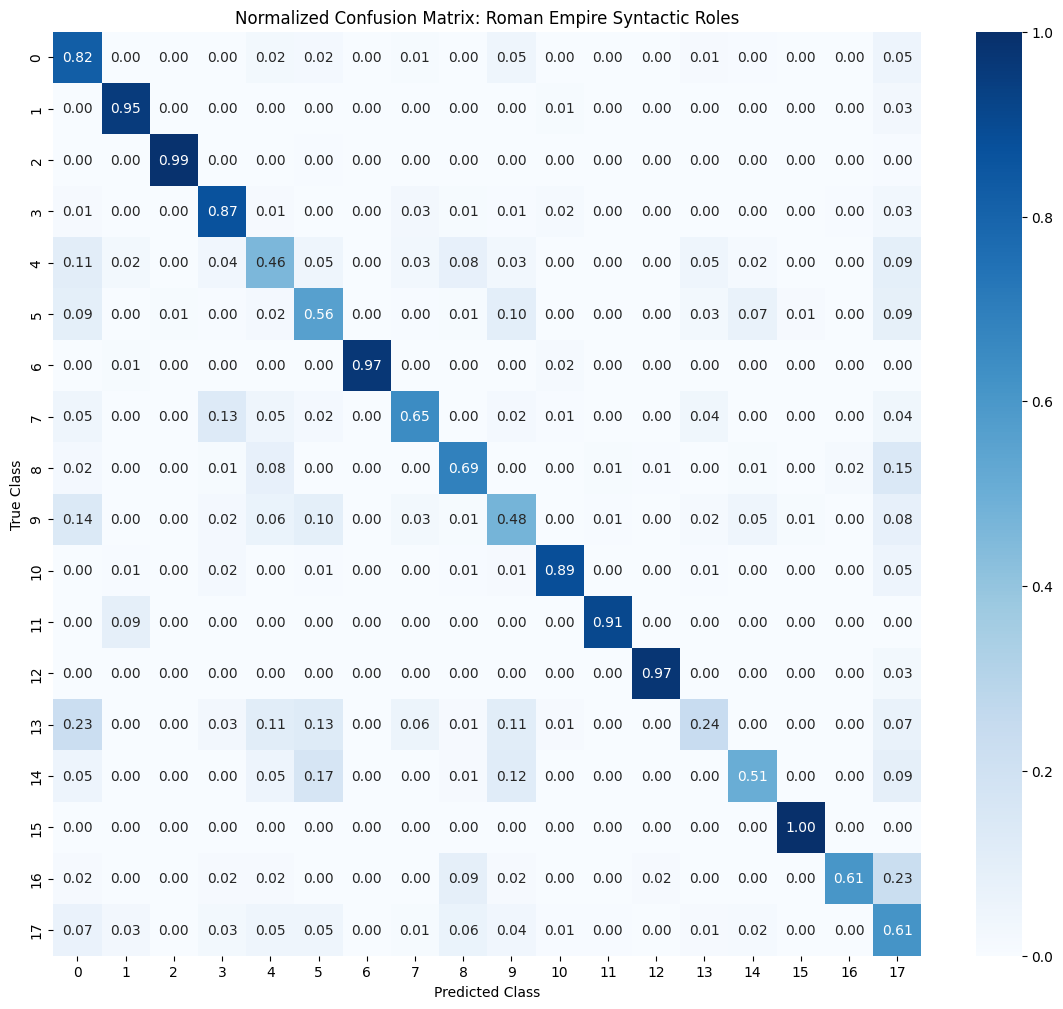

Training Time 47.87777638435364


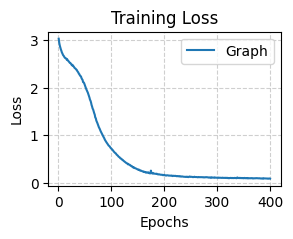

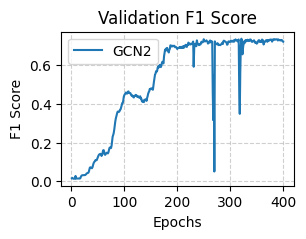

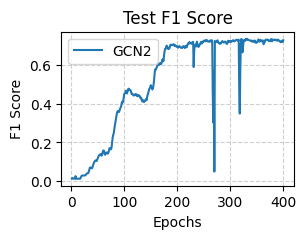

In [59]:
gcn2_run()

# H2GCN

In [27]:
from H2GCN import H2GCN

In [38]:
args = {
      'device': device,
      'num_layers': 30, #Not applicable to H2GCN
      'hidden_dim': 300,
      'dropout': 0.5,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [39]:
def h2GCN_run():
    model = H2GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training H2GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'H2GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'H2GCN','F1 Score')


Training H2GCN
Epoch: 010, Loss: 1.4428, Val F1: 0.2423,Val Acc: 0.3538, Time: 0.01s
Epoch: 020, Loss: 1.0452, Val F1: 0.2151,Val Acc: 0.3277, Time: 0.01s
Epoch: 030, Loss: 0.8423, Val F1: 0.2772,Val Acc: 0.3827, Time: 0.01s
Epoch: 040, Loss: 0.6973, Val F1: 0.3224,Val Acc: 0.4308, Time: 0.01s
Epoch: 050, Loss: 0.5827, Val F1: 0.3500,Val Acc: 0.4531, Time: 0.01s
Epoch: 060, Loss: 0.5143, Val F1: 0.4024,Val Acc: 0.5086, Time: 0.01s
Epoch: 070, Loss: 0.4678, Val F1: 0.5281,Val Acc: 0.6332, Time: 0.01s
Epoch: 080, Loss: 0.4112, Val F1: 0.6158,Val Acc: 0.6938, Time: 0.01s
Epoch: 090, Loss: 0.3838, Val F1: 0.6551,Val Acc: 0.7243, Time: 0.01s
Epoch: 100, Loss: 0.3685, Val F1: 0.6701,Val Acc: 0.7347, Time: 0.01s
Test F1: 0.6669
Test Accuracy: 0.7219


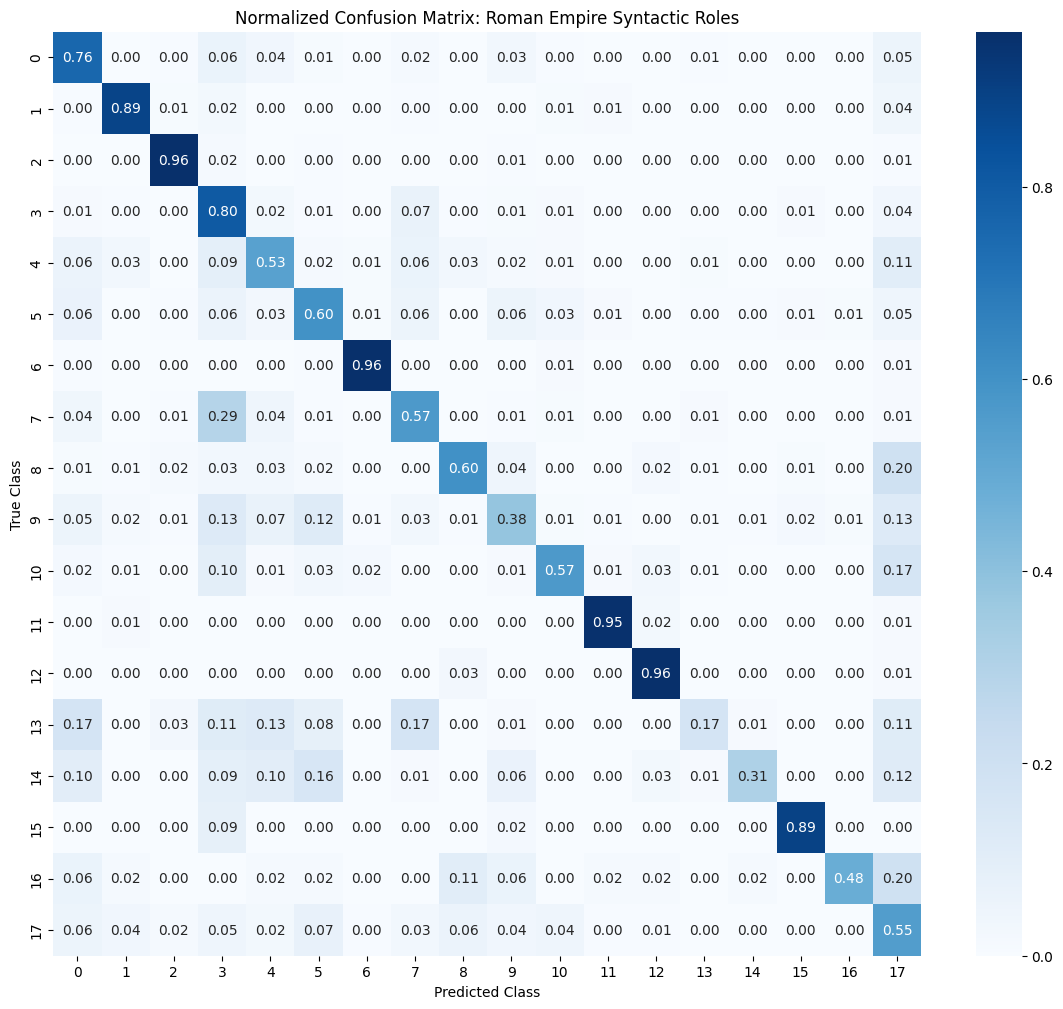

Training Time 7.501018524169922


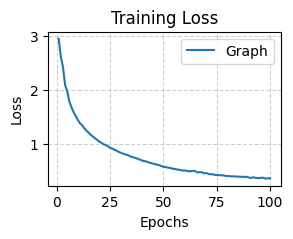

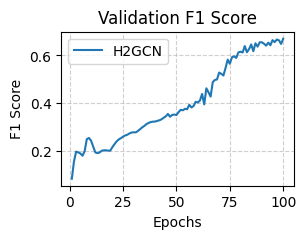

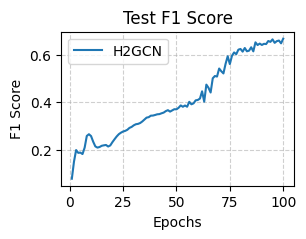

In [41]:
h2GCN_run()